In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Leitura do arquivo

arquivo = 'photon4.64E15_array'

df = pl.read_csv(arquivo, has_header= False).filter(pl.col('column_1').str.contains('TRIG'))

df = df.with_columns(pl.col("column_1").str.split(" ").alias("split_column"))
df = df.with_columns(pl.col("split_column").list.get(0).alias("TRIG"))
df = df.with_columns(pl.col("split_column").list.get(1).cast(pl.Int64).alias("count"))

df

column_1,split_column,TRIG,count
str,list[str],str,i64
"""TRIG1 9""","[""TRIG1"", ""9""]","""TRIG1""",9
"""TRIG2 15""","[""TRIG2"", ""15""]","""TRIG2""",15
"""TRIG3 14""","[""TRIG3"", ""14""]","""TRIG3""",14
"""TRIG4 11""","[""TRIG4"", ""11""]","""TRIG4""",11
"""TRIG5 15""","[""TRIG5"", ""15""]","""TRIG5""",15
"""TRIG6 15""","[""TRIG6"", ""15""]","""TRIG6""",15
"""TRIG7 20""","[""TRIG7"", ""20""]","""TRIG7""",20
"""TRIG8 11""","[""TRIG8"", ""11""]","""TRIG8""",11
"""TRIG9 12""","[""TRIG9"", ""12""]","""TRIG9""",12


In [3]:
import re
def formatar_string(s):
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', s)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return s

name = formatar_string(arquivo)
name

'Iron 4.64E15'

In [6]:
# Transformação das contagens de partículas em listas e na média de contagens

df2 = df.group_by('TRIG').agg(pl.col("count")).sort(
    pl.col("TRIG").str.extract(r"TRIG([0-9]*)", 1).cast(int)
)
df2 = df2.with_columns(mean_count = pl.col('count').list.mean())  
df2

TRIG,count,mean_count
str,list[i64],f64
"""TRIG1""","[9, 6, … 20]",5.4
"""TRIG2""","[15, 3, … 30]",7.44
"""TRIG3""","[14, 7, … 37]",9.63
"""TRIG4""","[11, 7, … 43]",11.97
"""TRIG5""","[15, 10, … 41]",13.63
"""TRIG6""","[15, 14, … 43]",13.38
"""TRIG7""","[20, 13, … 61]",12.28
"""TRIG8""","[11, 13, … 35]",10.17
"""TRIG9""","[12, 9, … 29]",7.73


In [5]:
# Lista dos TRIGS com valores da média 

trigs = df2['mean_count'].to_list()

In [6]:
# Posição dos tanques

numDetectors = 100
gridSize = 10
spacing = 10
area = 1.0

x_det = np.zeros(numDetectors)
y_det = np.zeros(numDetectors)
areas = np.full(numDetectors, area)

index = 0
halfGridSize = gridSize // 2

for i in range(gridSize):
    for j in range(gridSize):
        x_det[index] = (j - halfGridSize + 0.5) * spacing
        y_det[index] = (i - halfGridSize + 0.5) * spacing
        areas[index] = area
        index += 1

print("x_det:", x_det)
print("y_det:", y_det)
print("areas:", areas)


x_det: [-45. -35. -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.
  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.
  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35.
 -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.
  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.  35.  45.
 -45. -35. -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.
  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.
  35.  45.]
y_det: [-45. -45. -45. -45. -45. -45. -45. -45. -45. -45. -35. -35. -35. -35.
 -35. -35. -35. -35. -35. -35. -25. -25. -25. -25. -25. -25. -25. -25.
 -25. -25. -15. -15. -15. -15. -15. -15. -15. -15. -15. -15.  -5.  -5.
  -5.  -5.  -5.  -5.  -5.  -5.  -5.  -5.   5.   5.   5.   5.   5.   5.
   5.   5.   5.   5.  15.  15.  15.  15.  15.  15.  15.  15.  15.  15.
  25.  25.  25.  25.  25.  25.  25.  25.  25.  25.  35.  35.  35.  35.
  35.  35.  35.  35.  35.  35.  45.  45.  45.  45. 

Text(62.722222222222214, 0.5, 'y (m)')

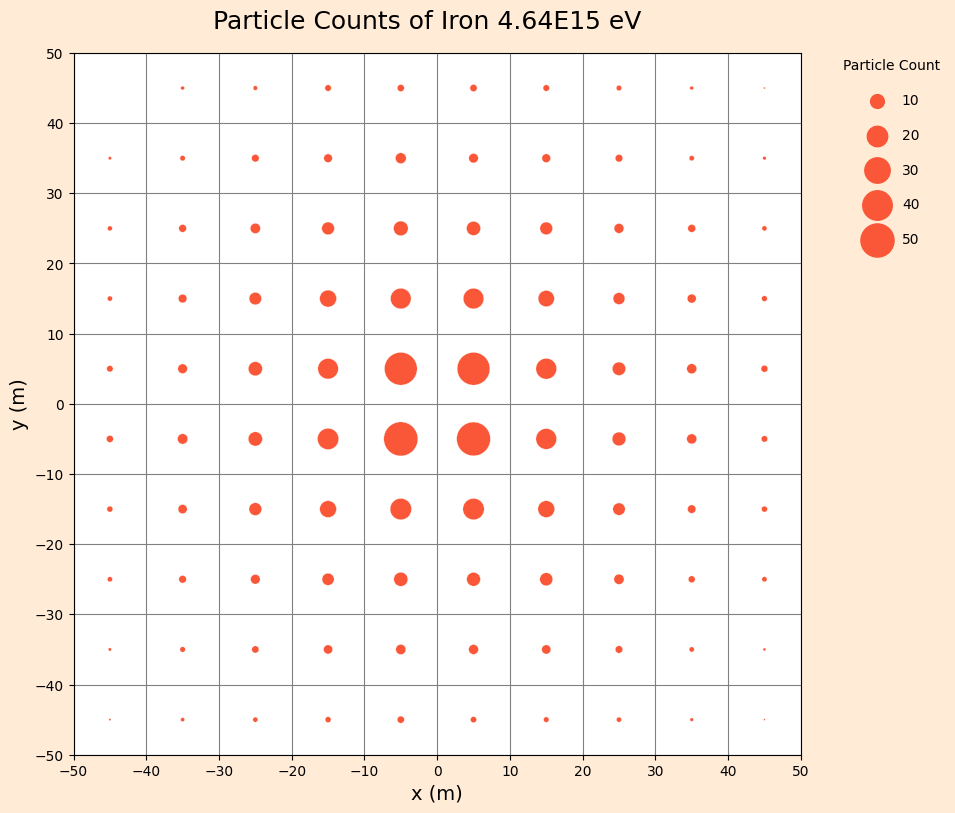

In [7]:
# Plot de partículas por tanque
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Particle Counts of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

scatter = sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', size=trigs, sizes=(0, 600), legend = 'brief')
handles, labels = scatter.get_legend_handles_labels()
for handle in handles:
    handle.set_color('#F95738')
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,
           frameon=False, title='Particle Count', labelspacing = 1.5)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


#plt.savefig('plots/counts_' + str(arquivo) + '.png', bbox_inches = 'tight', dpi = 300)

In [8]:
# O primeiro índice é o trig do tanque, e o segundo é o evento. Apenas um exemplo
df2['count'][0][0]*x_det[0]+df2['count'][1][0]*x_det[1]+ df2['count'][2][0]*x_det[2]/(df2['count'][0][0]+df2['count'][1][0]+df2['count'][2][0])

-233.57142857142858

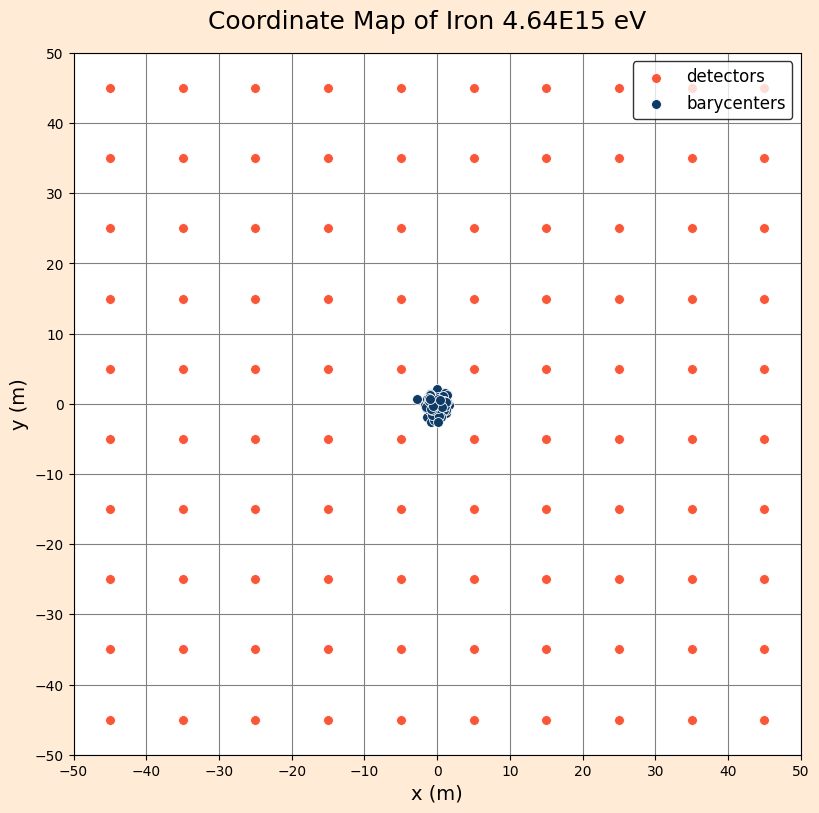

In [9]:
# Posição dos baricentros
x_b = [0] * len(trigs)
y_b = [0] * len(trigs)

for i in range(len(trigs)):
        numerator = 0
        numerator1 = 0
        denominator = 0
        for j in range(len(trigs)):
                numerator += (df2['count'][j][i]*x_det[j])
                numerator1 += (df2['count'][j][i]*y_det[j])
                denominator += (df2['count'][j][i])
                if denominator != 0: 
                    x_b[i] = numerator / denominator
                    y_b[i] = numerator1 / denominator
                else:
                    x_b[i] = 0 
                    y_b[i] = 0 

fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)
sns.scatterplot(x = x_b, y = y_b, ax = ax, color = '#0D3B66',s = 50)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

#plt.savefig('plots/map_' + str(arquivo) + '.png',bbox_inches = 'tight', dpi = 300)

In [11]:
# Criação de arquivo de dados para construir a função de distribuição lateral

r_b = []
for i in range(100):
    aux = ((x_det[i]-x_b[i])**2 + (y_det[i]-y_b[i])**2)**0.5
    r_b.append(aux)


df3 = df2.with_columns(
    pl.Series(name='x_b', values=x_b),
    pl.Series(name='y_b', values=y_b),
    pl.Series(name='r_b', values=r_b)
)

df3 = df3.drop('count')
#df3.write_csv('array_dat/' + arquivo + '_fdl.csv', separator= '\t', has_header= False)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


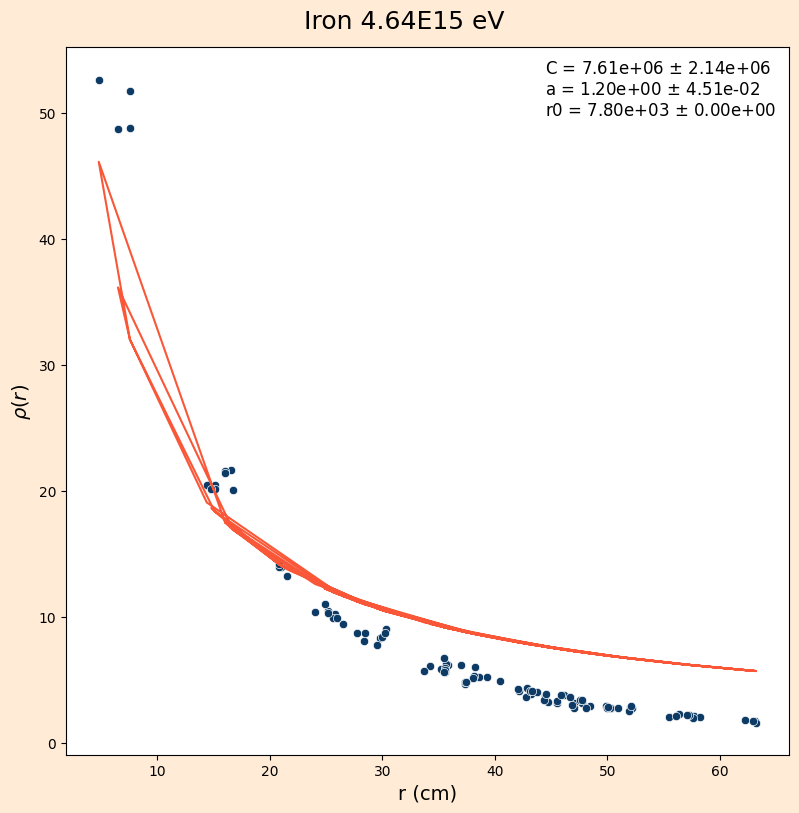

In [12]:
from scipy.optimize import curve_fit
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle(str(name) + ' eV', size = 18)
sns.scatterplot(x = r_b, y = df2['mean_count'], ax = ax, color = '#0D3B66')
fig.tight_layout()

ax.set_xlabel('r (cm)', size = 14)
ax.set_ylabel(r'$\rho(r)$', size = 14)

#ax.set_xlim(xmin=0)
#ax.set_ylim(ymin=0)
r_b = np.array(r_b)

r0 = 7800
p0 = (1000,1.334)
def f_model(x, c, s):
    # Verificação para evitar overflow
    with np.errstate(over='ignore'):
        return ((c / r0**2) * (x / r0)**(s-2) * (1 + x / r0)**(s-4.5))

popt, pcov = curve_fit(
    f=f_model,
    xdata=r_b,
    ydata=df2['mean_count'],
    p0=p0,
    bounds = ([0, 1.2], [np.inf, 2.2])
)
c_opt, s_opt = popt
inc = np.sqrt(np.diag(pcov))

y = f_model(r_b, c_opt, s_opt)

plt.plot(r_b, y, color='#F95738')

ax.legend(title='C = {:.2e} $\pm$ {:.2e}\na = {:.2e} $\pm$ {:.2e}\nr0 = {:.2e} $\pm$ {:.2e}'
          .format(c_opt, inc[0], s_opt, inc[1], r0, 0),  # r0 é constante aqui, então a incerteza é zero
          title_fontsize=12, facecolor='white', frameon=False)

# plt.savefig('plots/fit_' + str(arquivo) + '.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_7144/440878046.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[1.24850214e-19 4.91377565e-02]
[2.46620839 2.97899467 3.49431229 4.00870826 4.52149455 5.03681216]


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
2.395676,14.0,13.954274,0.326615
3.088845,14.332438,14.403654,0.496883
3.460296,14.666518,14.644465,0.150359
4.024896,15.0,15.010494,0.069963
4.504199,15.332438,15.321226,0.073131
5.032619,15.666518,15.663799,0.017353


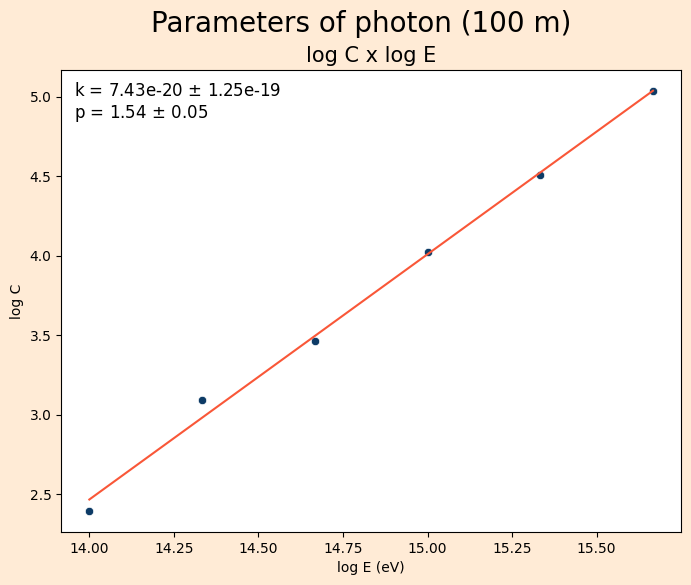

In [21]:
# Fit do fóton

C = [248.7,1227,2886,1.059E4,3.193E4,1.078E5]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_photon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_photon))

ax.plot(logE, power(E,*coefficients_photon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_photon[0],inc[0],coefficients_photon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_photon[0]))/coefficients_photon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

/tmp/ipykernel_7144/3286765876.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[1.03038040e-14 1.83578977e-01]


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
2.601843,14.0,14.067571,0.482653
3.087426,14.332438,14.460463,0.89325
3.256477,14.666518,14.597244,0.472328
3.340246,15.0,14.665022,2.233186
4.198932,15.332438,15.359795,0.178425
4.802089,15.666518,15.847817,1.15724


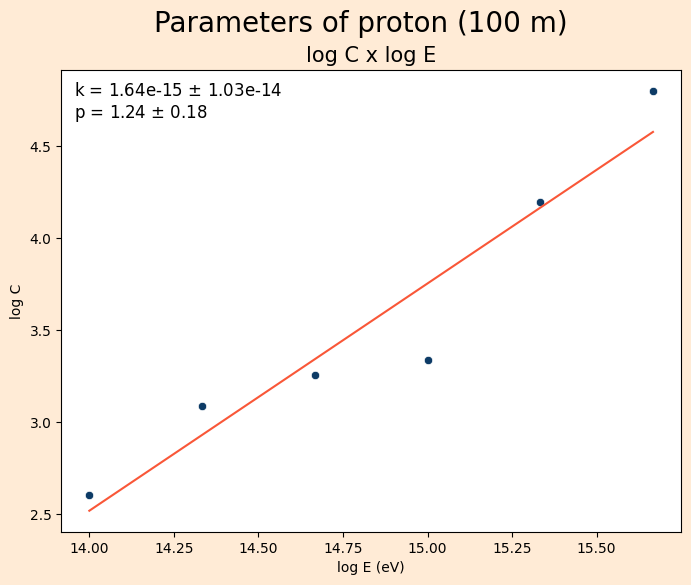

In [22]:
# Fit do próton

C = [399.8,1223,1805,2189,1.581E4,6.34E4]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_proton, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

ax.plot(logE, power(E,*coefficients_proton), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_proton[0],inc[0],coefficients_proton[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_proton[0]))/coefficients_proton[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

/tmp/ipykernel_7144/1979787981.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[4.16967135e-23 9.31251377e-02]


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
1.252853,14.0,13.90013,0.713354
2.130977,14.332438,14.405858,0.512263
2.646992,14.666518,14.703041,0.249021
3.245513,15.0,15.04774,0.318268
3.7406,15.332438,15.33287,0.002814
4.218798,15.666518,15.608273,0.371778


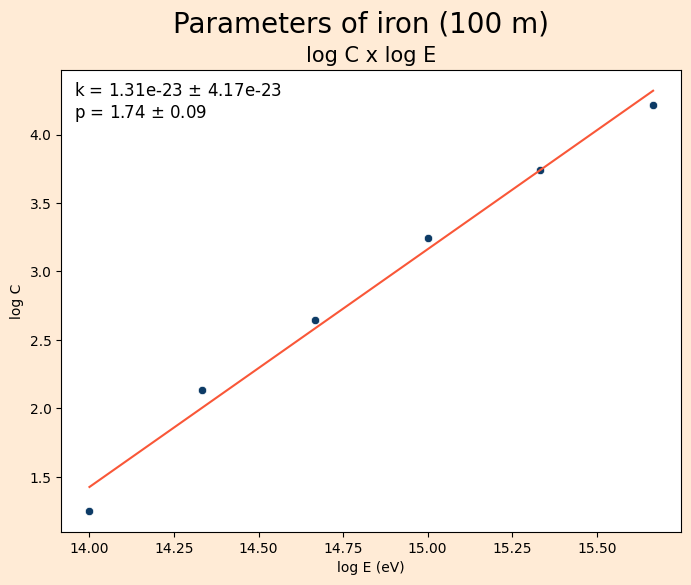

In [24]:
# Fit do ferro

C = [17.9,135.2,443.6,1760,5503,1.655E4]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_iron, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

ax.plot(logE, power(E,*coefficients_iron), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_iron[0],inc[0],coefficients_iron[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_iron[0]))/coefficients_iron[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [27]:
# Reconstrução da energia

E_real = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
r0 = 7800

# Parâmetros fóton

k_photon = coefficients_photon[0] 
p_photon = coefficients_photon[1] 
c_photon = [1975,5697,1.273E5,7.89E4,1.368E5,4.35E5] # Array 10x10
E_photon = []


for i in range(len(c_photon)):
    E = (c_photon[i]/k_photon)**(1/p_photon)
    E_photon.append(E)
    #N = ((c_photon[i])/((r0**(s_photon[i]))))*(1000**((s_photon[i]-1))/(s_photon[i]-1))*math.pi*1000**2
    #N_photon.append(N)
    #print('{:e}'.format(E_photon[i]))


# Parâmetros próton

k_proton = coefficients_proton[0]
p_proton = coefficients_proton[1]
c_proton = [2894,6269,1.609E4,4.776E4,1.028E5,2.606E5]
E_proton = []

for i in range(len(c_photon)):
    E = (c_proton[i]/k_proton)**(1/p_proton)
    E_proton.append(E)
    #print('{:e}'.format(E_proton[i]))

# Parâmetros ferro

k_iron = coefficients_iron[0]
p_iron = coefficients_iron[1]
c_iron = [293.8,3226,6020,1.778E4,5.223E4,1.058E5]
s_iron = [2.033,2.097,1.778,1.645,1.606,1.431]
E_iron = []

for i in range(len(c_iron)):
    E = (c_iron[i]/k_iron)**(1/p_iron)
    E_iron.append(E)
    #print('{:e}'.format(E_iron[i]))


data = {
    'E':E_real,
    'E_photon':E_photon,
    'E_proton':E_proton,
    'E_iron':E_iron
}

df = pl.DataFrame(data)
df

E,E_photon,E_proton,E_iron
f64,f64,f64,f64
1.0000e14,3.4488e14,5.7960e14,3.9809e14
2.1500e14,6.8539e14,1.0833e15,1.5823e15
4.6400e14,5.1359e15,2.3225e15,2.2664e15
1.0000e15,3.7664e15,5.6011e15,4.2287e15
2.1500e15,5.3812e15,1.0415e16,7.8655e15
4.6400e15,1.1392e16,2.2106e16,1.1811e16


[Text(0.5, 1.0, 'Energy Diversion')]

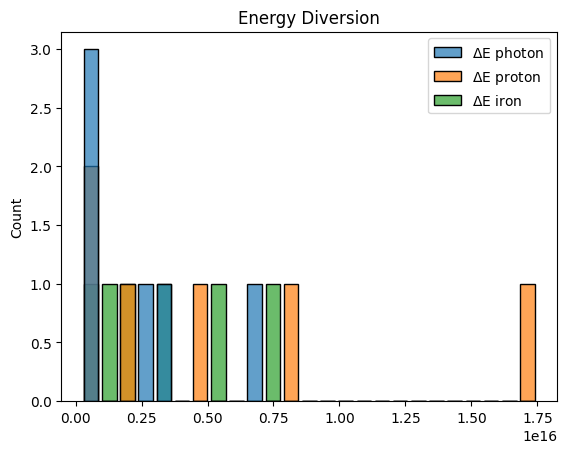

In [26]:
DeltaE_photon = []
DeltaE_proton = []
DeltaE_iron = []

for i in range(len(E_real)):
    aux = abs(E_real[i] - E_photon[i])
    aux2 = abs(E_real[i] - E_proton[i])
    aux3 = abs(E_real[i] - E_iron[i])
    DeltaE_photon.append(aux)
    DeltaE_proton.append(aux2)
    DeltaE_iron.append(aux3)

data = {
    '$\Delta$E photon':DeltaE_photon,
    '$\Delta$E proton':DeltaE_proton,
    '$\Delta$E iron':DeltaE_iron
}

sns.histplot(data=data, bins= 25, shrink=0.8, alpha = 0.7).set(title = 'Energy Diversion')